In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

Estimated coefficients: [ 1.84548879  3.11265725  5.00934908 10.03745763]


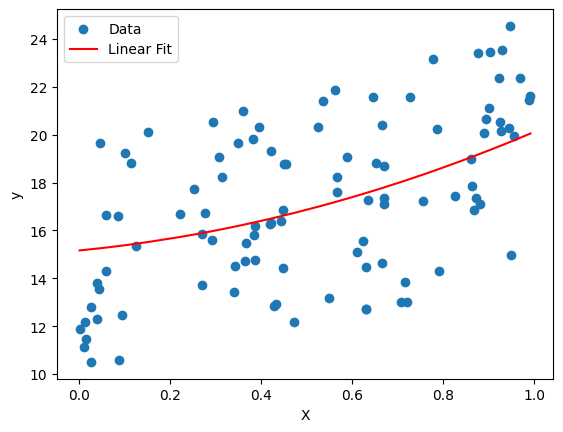

In [14]:
n = 100
x1 = np.random.uniform(0, 1, n)
X = np.column_stack((x1, x1**2, np.random.uniform(0, 2, n), np.ones(n)))
n, p = X.shape
y = 2 * X[:, 0] + 3 * X[:,1] + 5 * X[:, 2] + 10 * X[:, 3] + np.random.normal(0, 0.1, n)
B = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated coefficients:", B)
y_pred = X @ B
# plot data
X_pred = np.column_stack((X[:, 0], X[:, 1], np.mean(X[:, 2]) * np.ones(n), np.ones(n)))
X_pred = X_pred[np.argsort(X_pred[:, 0])]
y_plot = X_pred @ B
plt.scatter(X[:, 0], y, label='Data')
plt.plot(X_pred[:, 0], y_plot, color='red', label='Linear Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [15]:
# beta error calculation
y_error = y - y_pred
mse = np.mean(y_error**2)
print("Mean Squared Error:", mse)
B_error = np.sqrt(mse * np.linalg.inv(X.T @ X).diagonal())
alpha = 0.05
ci_lower = B - 1.96 * B_error
ci_upper = B + 1.96 * B_error
t_values = B/B_error
p_values = 2 * (1 - t.cdf(np.abs(t_values), df=n-p))
print(f"Coefficients: {B}, Standard Errors: {B_error}, 95% CI: [{ci_lower}, {ci_upper}], p-values: {p_values}")

Mean Squared Error: 0.008283616151358785
Coefficients: [ 1.84548879  3.11265725  5.00934908 10.03745763], Standard Errors: [0.11326776 0.11008333 0.0160543  0.02825183], 95% CI: [[1.62348398 2.89689393 4.97788266 9.98208405], [ 2.0674936   3.32842057  5.0408155  10.09283122]], p-values: [0. 0. 0. 0.]
